Modeling Rydberg atoms in the lab
==================================

The folks at Sandia have been testing the laser in a spin echo (or CPMG). We want to model what we expect to see in this spin echo.

In [1]:
using QuantumOptics
using RydbergUtils

H_x_πHalf = blockade_R(e_x*π/2, 1) ⊕ blockade_R(e_x*π/2, 1)
H_x_π = blockade_R(e_x*π, 1) ⊕ blockade_R(e_x*π, 1)
H_uv = iba_Hamiltonian_blockade(T=1)

empty_echo = CompositeHamiltonianTL([H_x_πHalf, H_x_π, H_x_πHalf])
CZ = CompositeHamiltonianTL([H_uv, H_uv])
b_01, b_0r, b_11, b_B = blockade_states
;
# CZ_spin_echo = CompositeHamiltonianTL([H_x_πHalf, H_uv, H_x_π, H_uv, H_x_πHalf])


In [2]:

display("Empty Echo")

T = totalTime(empty_echo)
display("|01>")
display(schroedingerTimeEvolve(b_01, empty_echo))
display("|11>")
display(schroedingerTimeEvolve(b_11, empty_echo))




"Empty Echo"

"|01>"

1-element Vector{Ket{SumBasis{Vector{Int64}, Tuple{SpinBasis{1//2, Int64}, SpinBasis{1//2, Int64}}}, Vector{ComplexF64}}}:
 Ket(dim=4)
  basis: [Spin(1/2) ⊕ Spin(1/2)]
                 0.0 + 5.75390933e-8im
 -0.9999998334559026 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im

"|11>"

1-element Vector{Ket{SumBasis{Vector{Int64}, Tuple{SpinBasis{1//2, Int64}, SpinBasis{1//2, Int64}}}, Vector{ComplexF64}}}:
 Ket(dim=4)
  basis: [Spin(1/2) ⊕ Spin(1/2)]
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 5.75390933e-8im
 -0.9999998334559026 + 0.0im

In [3]:

display("Just CZ")

T = totalTime(CZ)
display("|01>")
res01 = schroedingerTimeEvolve(b_01, CZ)
display(res01)

display("|11>")
res11 = schroedingerTimeEvolve(b_11, CZ)
display(res11)

ϕ_1 = angle(b_01' * res01[end])
ϕ_2 = angle(b_11' * res11[end])
display("$((ϕ_2 - 2ϕ_1)/π)π")

"Just CZ"

"|01>"

1-element Vector{Ket{SumBasis{Vector{Int64}, Tuple{SpinBasis{1//2, Int64}, SpinBasis{1//2, Int64}}}, Vector{ComplexF64}}}:
 Ket(dim=4)
  basis: [Spin(1/2) ⊕ Spin(1/2)]
 -0.00308825044815386 - 0.00350349568541479im
   0.8367861147242707 + 0.5475089248886392im
                  0.0 + 0.0im
                  0.0 + 0.0im

"|11>"

1-element Vector{Ket{SumBasis{Vector{Int64}, Tuple{SpinBasis{1//2, Int64}, SpinBasis{1//2, Int64}}}, Vector{ComplexF64}}}:
 Ket(dim=4)
  basis: [Spin(1/2) ⊕ Spin(1/2)]
                  0.0 + 0.0im
                  0.0 + 0.0im
 -0.04843502327042516 - 0.05494683342954865im
  -0.7687114415145602 - 0.635385676401029im

"-1.1489870641368842π"

Now I am switching to the full 9 level system

In [4]:
using QuantumOptics

ibaH = iba_Hamiltonian(T=1.1, Vrr=1000)
CZ = CompositeHamiltonianTL([ibaH,ibaH])

T = totalTime(CZ)

display("|00>")
res00 = timeevolution.schroedinger_dynamic([0, T], s00, forTimeEvolution(CZ))
display(res00)

display("|01>")
res01 = timeevolution.schroedinger_dynamic([0, T], s01, forTimeEvolution(CZ))
display(res01)

display("|11>")
res11 = timeevolution.schroedinger_dynamic(range(0, T, 100), s11, forTimeEvolution(CZ))
display(res11)

ϕ_global = angle(s00' * res00[2][end])
ϕ_LS = angle(s01' * res01[2][end]) - ϕ_global
ϕ_2 = angle(s11' * res11[2][end]) - ϕ_global - 2(ϕ_LS)

display("Removing Global Phase")
display("Phase of |00> $(ϕ_global-ϕ_global)π")
display("Phase of |01> $(round(ϕ_LS/π, digits=3))π")
display("Phase of |11> $(round(ϕ_2/π, digits=3))π")

"|00>"

([0.0, 2.2], Ket{CompositeBasis{Vector{Int64}, Tuple{NLevelBasis{Int64}, NLevelBasis{Int64}}}, Vector{ComplexF64}}[Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im, Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im])

"|01>"

([0.0, 2.2], Ket{CompositeBasis{Vector{Int64}, Tuple{NLevelBasis{Int64}, NLevelBasis{Int64}}}, Vector{ComplexF64}}[Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im, Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
  0.6723396934957413 + 0.7343811226553127im
                 0.0 + 0.0im
                 0.0 + 0.0im
 0.04138240383542867 - 0.08313007935019895im
                 0.0 + 0.0im
                 0.0 + 0.0im])

"|11>"

([0.0, 0.022222222222222223, 0.044444444444444446, 0.06666666666666667, 0.08888888888888889, 0.1111111111111111, 0.13333333333333333, 0.15555555555555556, 0.17777777777777778, 0.2  …  2.0, 2.022222222222222, 2.0444444444444443, 2.066666666666667, 2.088888888888889, 2.111111111111111, 2.1333333333333333, 2.1555555555555554, 2.1777777777777776, 2.2], Ket{CompositeBasis{Vector{Int64}, Tuple{NLevelBasis{Int64}, NLevelBasis{Int64}}}, Vector{ComplexF64}}[Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im, Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
                 0.0 + 0.0im
  0.4416728488805175 + 0.8971555937493326im
 0.00343339013890484 - 0.00255974389439727im
                 0.0 + 0.0im
 0.00343339013890484 - 0.00255974389439727im
   -2.98375013564e-6 + 1.49880504773e-6im, Ket(dim=9)


"Removing Global Phase"

"Phase of |00> 0.0π"

"Phase of |01> 0.264π"

"Phase of |11> -0.891π"

In [5]:
using QuantumOptics
using RydbergUtils

ibaH = iba_Hamiltonian(Vrr=1000)
R(θ) = ramanLaser(e_x*θ, 1) ⊗ ramanLaser(e_x*θ, 1)
CZ = CompositeHamiltonianTL([R(π/2), ibaH, R(π), ibaH, R(π/2)])

T = round(totalTime(CZ), digits=10)

display("|00>")
res00 = timeevolution.schroedinger_dynamic([0, T], s00, forTimeEvolution(CZ))
display(res00)

display("|01>")
res01 = timeevolution.schroedinger_dynamic([0, T], s01, forTimeEvolution(CZ))
display(res01)

display("|11>")
res11 = timeevolution.schroedinger_dynamic([0, T], s11, forTimeEvolution(CZ))
display(res11)

ϕ_global = angle(s00' * res00[2][end])
ϕ_LS = angle(s01' * res01[2][end] - ϕ_global)
ϕ_2 = angle(s11' * res11[2][end]) - ϕ_global - 2(ϕ_LS)

display("Removing Global Phase")
display("Phase of |00> $(ϕ_global-ϕ_global)π")
display("Phase of |01> $(round(ϕ_LS/π, digits=3))π")
display("Phase of |11> $(round(ϕ_2/π, digits=3))π")


"|00>"

([0.0, 5.546332], Ket{CompositeBasis{Vector{Int64}, Tuple{NLevelBasis{Int64}, NLevelBasis{Int64}}}, Vector{ComplexF64}}[Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im, Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 -0.41047391132027594 + 0.7359237766955642im
                  0.0 + 0.0im
                  0.0 + 0.0im
                  0.0 + 0.0im
  -0.4805625652665899 + 0.2425097335778295im
  0.00159375824542952 - 0.00921885157933362im
                  0.0 + 0.0im
  0.00159375824542952 - 0.00921885157933362im
     6.10504572712e-6 + 7.19350278e-6im])

"|01>"

([0.0, 5.546332], Ket{CompositeBasis{Vector{Int64}, Tuple{NLevelBasis{Int64}, NLevelBasis{Int64}}}, Vector{ComplexF64}}[Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im, Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
                  0.0 + 0.0im
  0.23297696191429537 + 0.447047690204783im
 -0.04582406399807298 - 0.05261549766885344im
  -0.7311203366702443 + 0.38459578461454746im
                  0.0 + 0.0im
                  0.0 + 0.0im
  0.19666803217636367 - 0.14090221106241022im
                  0.0 + 0.0im
                  0.0 + 0.0im])

"|11>"

([0.0, 5.546332], Ket{CompositeBasis{Vector{Int64}, Tuple{NLevelBasis{Int64}, NLevelBasis{Int64}}}, Vector{ComplexF64}}[Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im, Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
  -0.4805431035748759 + 0.24236058912382663im
                  0.0 + 0.0im
                  0.0 + 0.0im
                  0.0 + 0.0im
   0.8349075877146813 + 0.1079554761484948im
 -0.00675561274351708 + 0.02758897426305182im
                  0.0 + 0.0im
 -0.00675561274351708 + 0.02758897426305182im
    -6.77742620545e-6 + 7.29831496854e-6im])

"Removing Global Phase"

"Phase of |00> 0.0π"

"Phase of |01> 0.957π"

"Phase of |11> -2.534π"

Two UV pulses followed by single qubit rotation
---------------------------------
Here we use $\ket{\psi_0}\rightarrow UV \rightarrow UV \rightarrow R_{\phi_1}^{\otimes2} \rightarrow CZ\ket{\psi_0}$

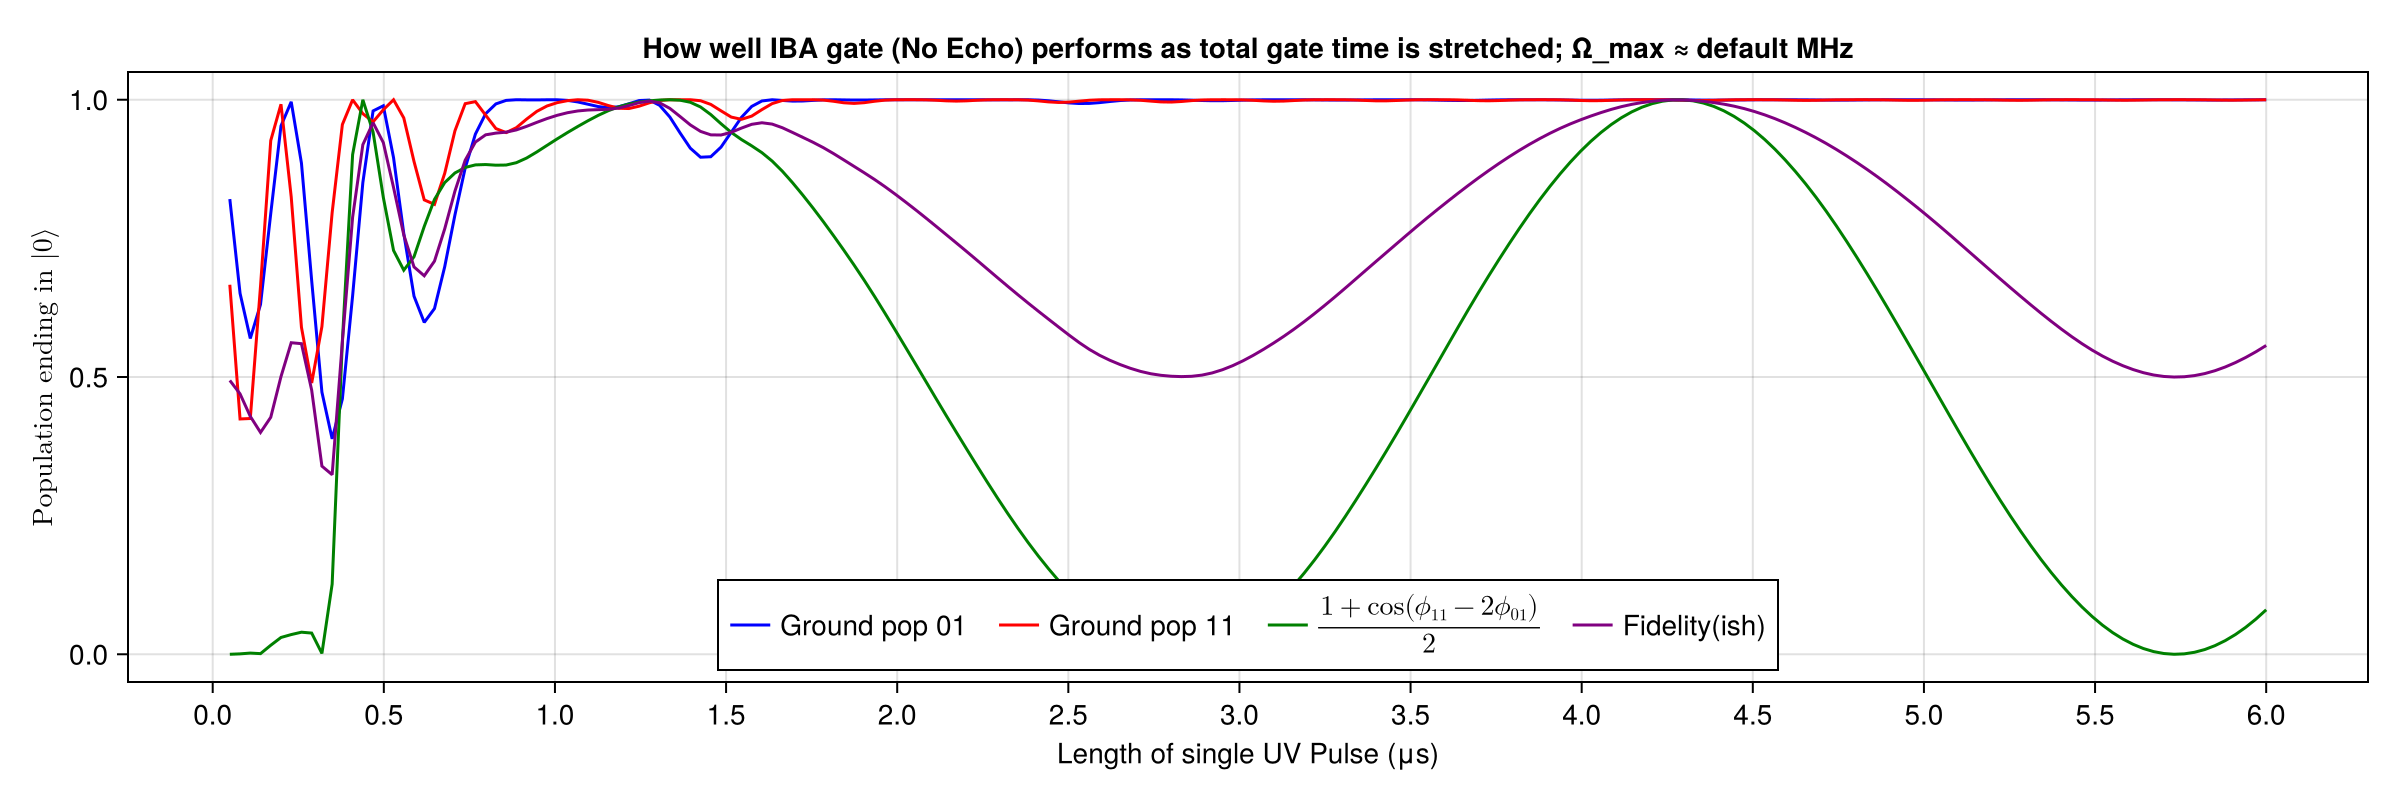

CairoMakie.Screen{IMAGE}


In [5]:
using CairoMakie
using RydbergUtils

iterations = 200
tmin = 0.05
tmax = 6
Ts = range(tmin, tmax, iterations)
Rx(θ) = ramanLaser(e_x*θ, 1)
I = identityTL(Rx(0))
Rx2(θ) = Rx(θ)⊗I + I⊗Rx(θ)

ibaHamiltonians = [iba_Hamiltonian(Vrr=500, T = T) for T in Ts]
CZs = [CompositeHamiltonianTL([ibaH_t, ibaH_t]) for ibaH_t in ibaHamiltonians]

plotting_values = test_entangling_gate.(CZs, upToSymmetricLocalOps=true)
ending_population_01 = getindex.(plotting_values, 1)
ending_population_11 = getindex.(plotting_values, 2)
cos_phase_accum = getindex.(plotting_values, 3)
fidelity = getindex.(plotting_values, 4)

# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well IBA gate (No Echo) performs as total gate time is stretched; Ω_max ≈ default MHz",
    xlabel = "Length of single UV Pulse (μs)",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (0:0.5:tmax)
)

# plotTs = Ts*totalTime(CZ)/Ts[end]
lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, Ts, cos_phase_accum, color = :green, label = L"\frac{1+\cos(\phi_{11} - 2\phi_{01})}{2}")
lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")
# vlines!(ax1, [T_opt])

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

In [17]:
maxF, index = findmax(fidelity[1:1:Int(length(fidelity)/2)])
maxF_time = Ts[index]
maxF_phase = getindex.(plotting_values, 5)[index]

println("F(t=$maxF_time)=$maxF")
println("ϕ₁(t=$maxF_time)=$maxF_phase")

F(t=1.2758793969849247)=0.9975486452334714
ϕ₁(t=1.2758793969849247)=-0.41018445786376817


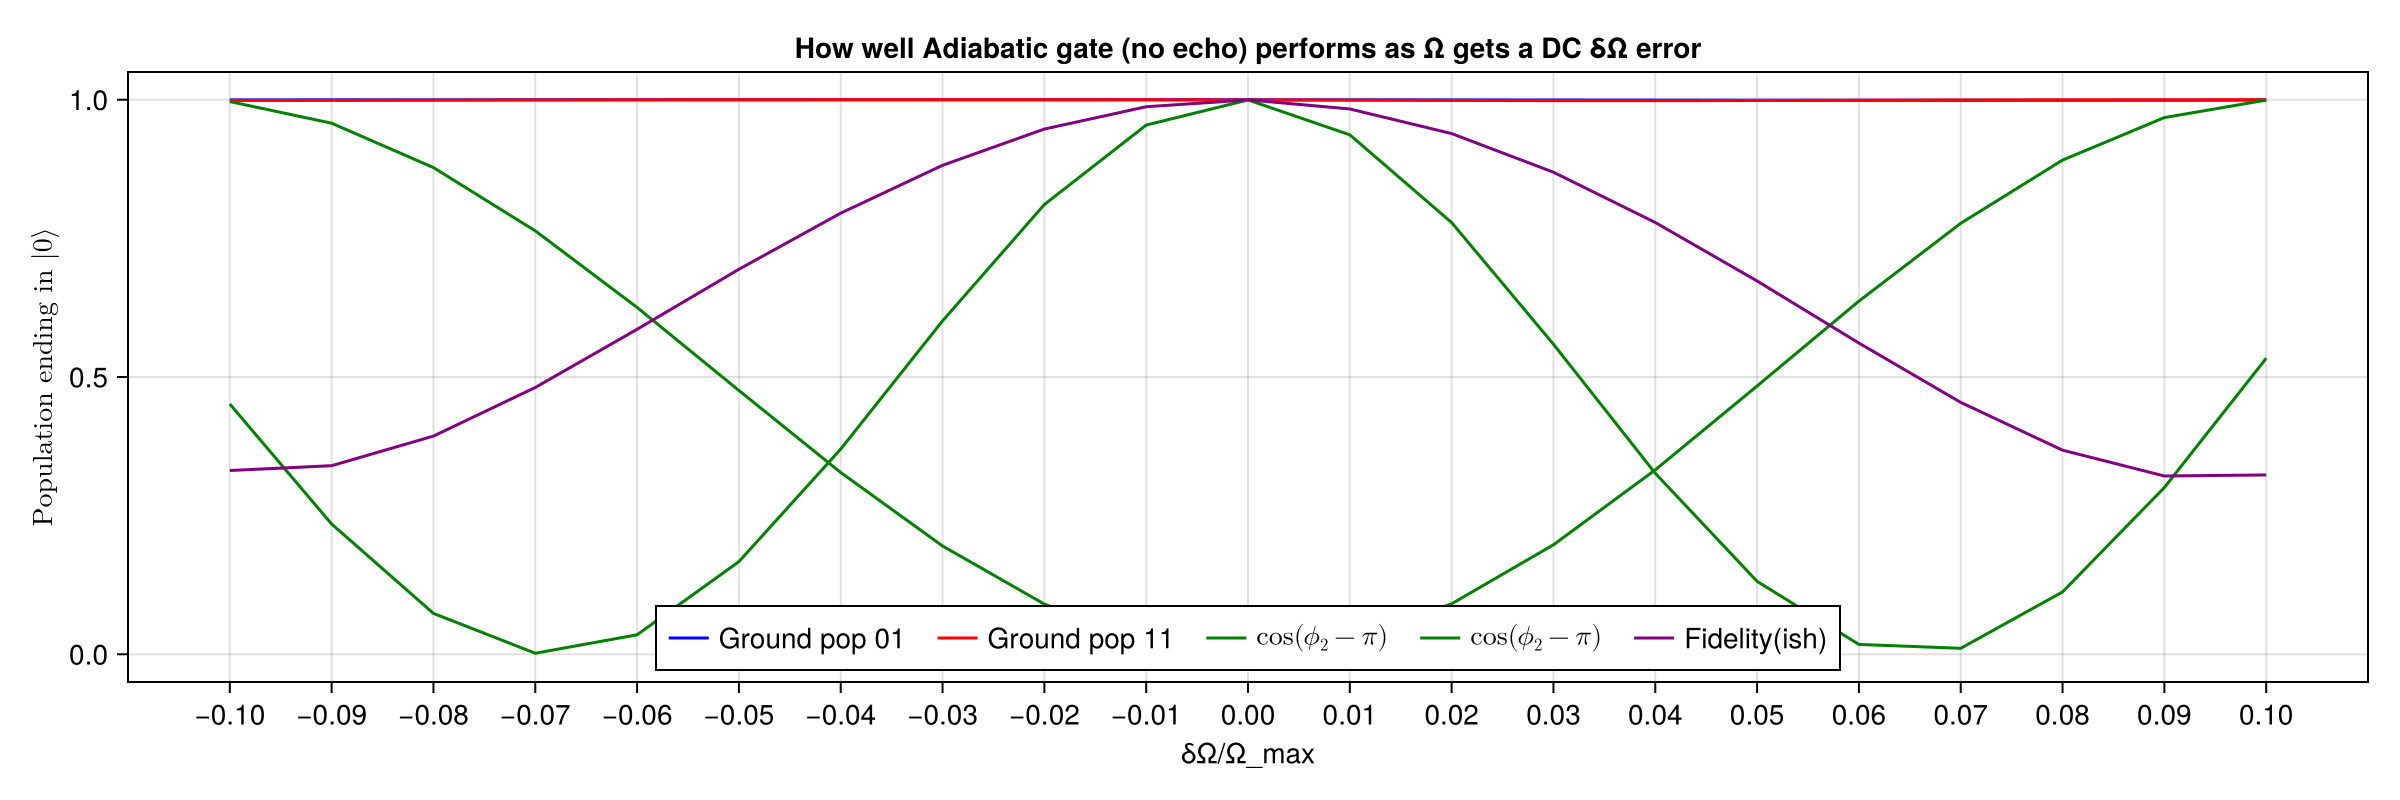

CairoMakie.Screen{IMAGE}


In [31]:
using CairoMakie
using RydbergUtils

Ω_max = 2.45025
δΩs = range(-0.1*Ω_max, 0.1*Ω_max, length=21)
Rx(θ) = ramanLaser(e_x*θ, 1)
Ry(θ) = ramanLaser(e_y*θ, 1)
Rz(θ) = ramanLaser(e_z*θ, 1)
I = identityTL(Rx(0))
Rx2(θ) = Rx(θ)⊗I + I⊗Rx(θ)
Ry2(θ) = Ry(θ)⊗I + I⊗Ry(θ)
Rz2(θ) = Rz(θ)⊗I + I⊗Rz(θ)

T_adiabatic = 4.26582914
T_IBA = 1.27317

ibaHamiltonians = [iba_Hamiltonian(Vrr=500, Ω_max=Ω_max+δΩ, T=T_adiabatic) for δΩ in δΩs]
CZs = [CompositeHamiltonianTL([ibaH, ibaH, Rz2(1.761)]) for ibaH in ibaHamiltonians]


plotting_values = test_entangling_gate.(CZs)
ending_population_01 = getindex.(plotting_values, 1)
ending_population_11 = getindex.(plotting_values, 2)
cos_phase01 = (1 .+ cos.(getindex.(plotting_values, 5) .- π))/2
cos_phase11 = (1 .+ cos.(getindex.(plotting_values, 6) .- π))/2
fidelity = getindex.(plotting_values, 4)

# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well Adiabatic gate (no echo) performs as Ω gets a DC δΩ error",
    xlabel = "δΩ/Ω_max",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (δΩs ./ Ω_max)
)

# plotTs = Ts*totalTime(CZ)/Ts[end]
lines!(ax1, (δΩs ./ Ω_max), ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, (δΩs ./ Ω_max), ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, (δΩs ./ Ω_max), cos_phase01, color = :green, label = L"\cos(\phi_2 - \pi)")
lines!(ax1, (δΩs ./ Ω_max), cos_phase11, color = :green, label = L"\cos(\phi_2 - \pi)")
lines!(ax1, (δΩs ./ Ω_max), fidelity, color = :purple, label = "Fidelity(ish)")
# vlines!(ax1, [T_opt])

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

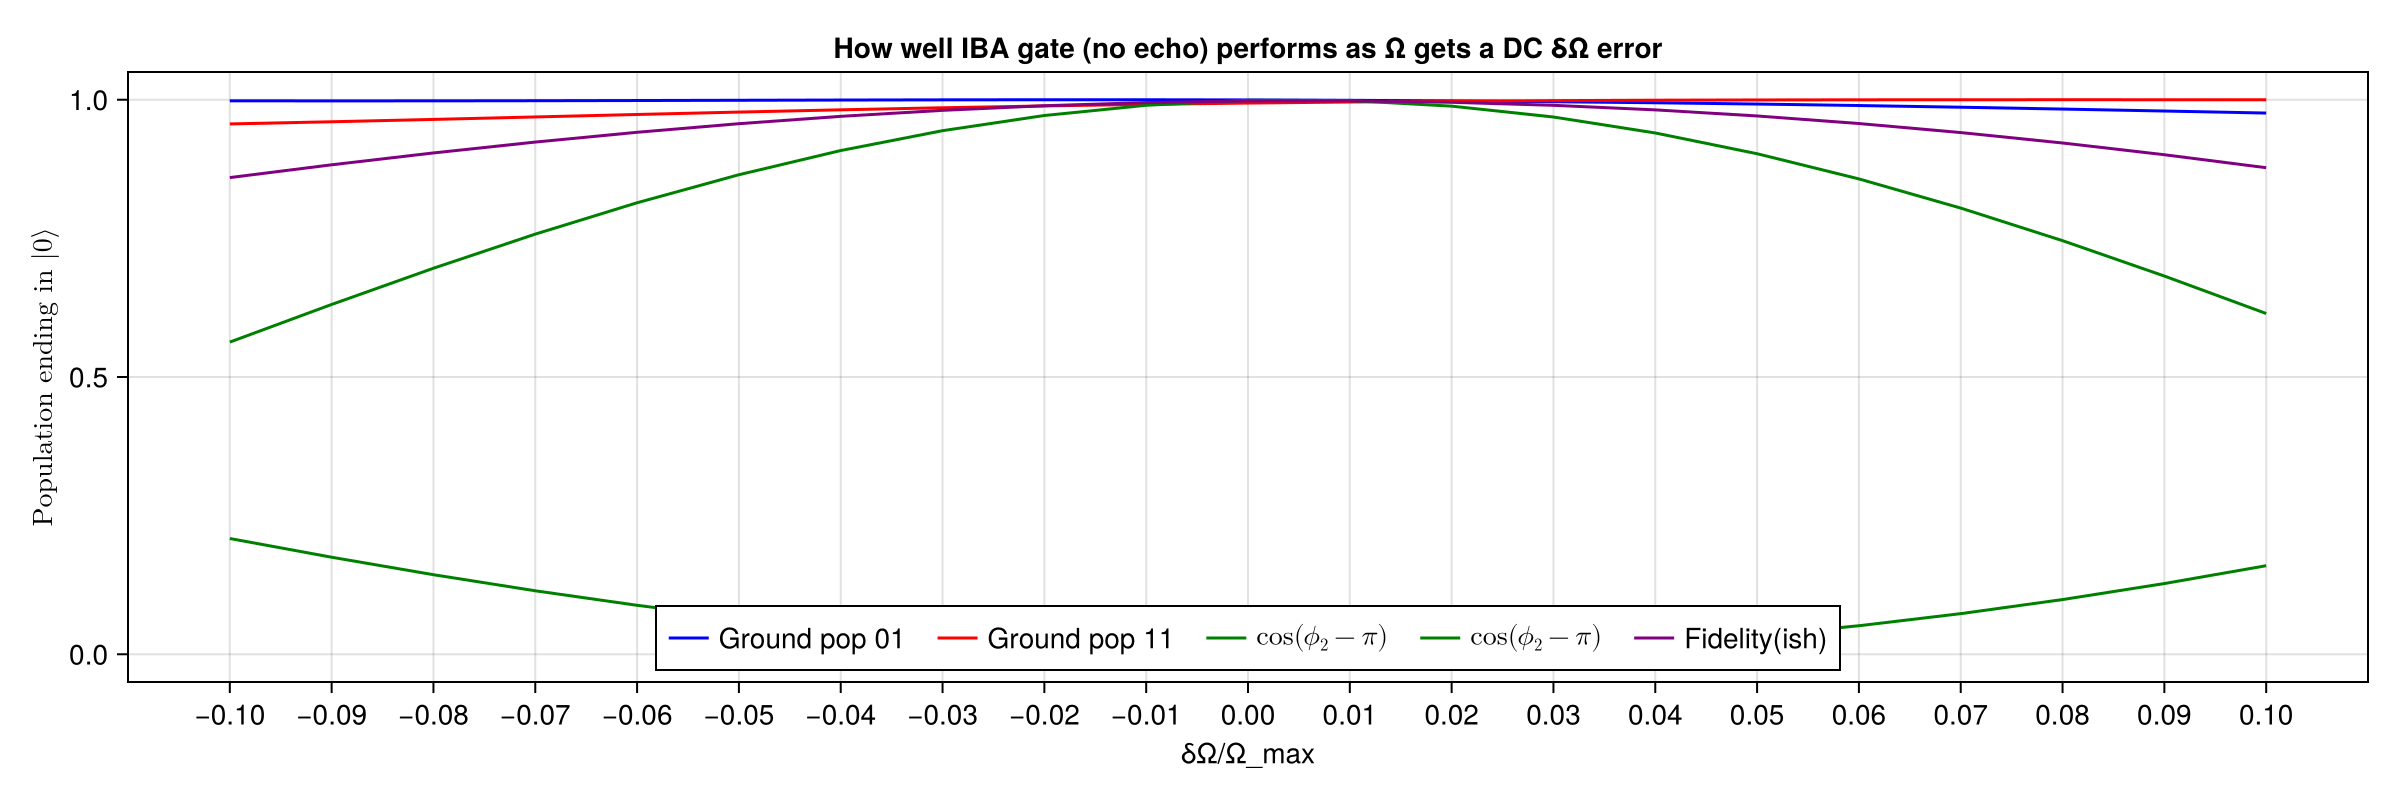

CairoMakie.Screen{IMAGE}


In [19]:
using CairoMakie
using RydbergUtils

Ω_max = 2.45025
δΩs = range(-0.1*Ω_max, 0.1*Ω_max, length=21)
Rx(θ) = ramanLaser(e_x*θ, 1)
Ry(θ) = ramanLaser(e_y*θ, 1)
Rz(θ) = ramanLaser(e_z*θ, 1)
I = identityTL(Rx(0))
Rx2(θ) = Rx(θ)⊗I + I⊗Rx(θ)
Ry2(θ) = Ry(θ)⊗I + I⊗Ry(θ)
Rz2(θ) = Rz(θ)⊗I + I⊗Rz(θ)

T_adiabatic = 4.26582914
T_IBA = 1.27317

ibaHamiltonians = [iba_Hamiltonian(Vrr=500, Ω_max=Ω_max+δΩ, T=T_IBA) for δΩ in δΩs]
CZs = [CompositeHamiltonianTL([ibaH, ibaH, Rz2(0.41018445786)]) for ibaH in ibaHamiltonians]


plotting_values = test_entangling_gate.(CZs)
ending_population_01 = getindex.(plotting_values, 1)
ending_population_11 = getindex.(plotting_values, 2)
cos_phase01 = (1 .+ cos.(getindex.(plotting_values, 5) .- π))/2
cos_phase11 = (1 .+ cos.(getindex.(plotting_values, 6) .- π))/2
fidelity = getindex.(plotting_values, 4)

# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well IBA gate (no echo) performs as Ω gets a DC δΩ error",
    xlabel = "δΩ/Ω_max",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (δΩs ./ Ω_max)
)

# plotTs = Ts*totalTime(CZ)/Ts[end]
lines!(ax1, (δΩs ./ Ω_max), ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, (δΩs ./ Ω_max), ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, (δΩs ./ Ω_max), cos_phase01, color = :green, label = L"\cos(\phi_2 - \pi)")
lines!(ax1, (δΩs ./ Ω_max), cos_phase11, color = :green, label = L"\cos(\phi_2 - \pi)")
lines!(ax1, (δΩs ./ Ω_max), fidelity, color = :purple, label = "Fidelity(ish)")
# vlines!(ax1, [T_opt])

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

Two UV pulses separated by echo $\pi$ pulse
---------------------------------
Here we use $\ket{\psi_0}\rightarrow UV  \rightarrow R_\pi \rightarrow UV  \rightarrow R_{?}^{\otimes2} \rightarrow CZ\ket{\psi_0}$

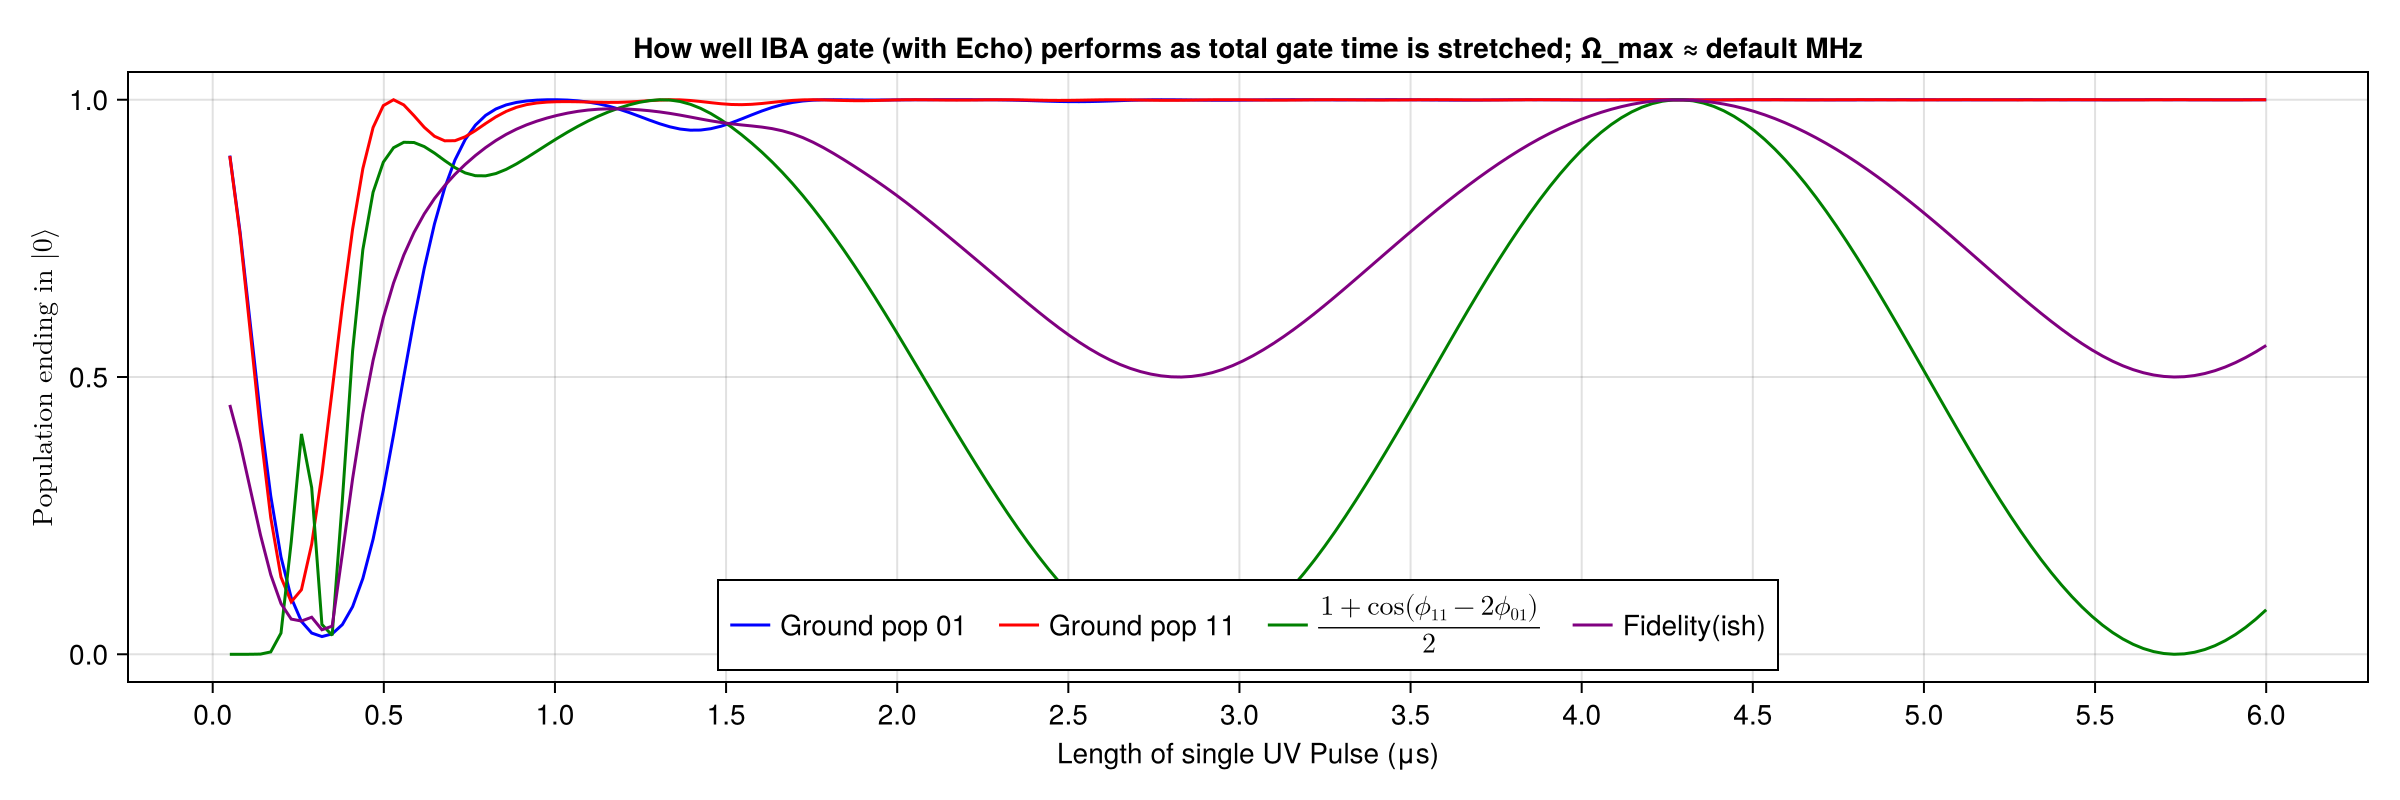

CairoMakie.Screen{IMAGE}


In [44]:
using CairoMakie
using RydbergUtils

iterations = 200
tmin = 0.05
tmax = 6
Ts = range(tmin, tmax, iterations)
Rx(θ) = ramanLaser(e_x*θ, 1)
I = identityTL(Rx(0))
Rx2(θ) = Rx(θ)⊗I + I⊗Rx(θ)

ibaHamiltonians = [iba_Hamiltonian(Vrr=500, T = T) for T in Ts]
CZs = [CompositeHamiltonianTL([Rx2(π), ibaH_t, Rx2(π), ibaH_t, Rz2(π/2)]) for ibaH_t in ibaHamiltonians]

plotting_values = test_entangling_gate.(CZs, upToSymmetricLocalOps=true)
ending_population_01 = getindex.(plotting_values, 1)
ending_population_11 = getindex.(plotting_values, 2)
cos_phase_accum = getindex.(plotting_values, 3)
fidelity = getindex.(plotting_values, 4)

# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well IBA gate (with Echo) performs as total gate time is stretched; Ω_max ≈ default MHz",
    xlabel = "Length of single UV Pulse (μs)",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (0:0.5:tmax)
)

# plotTs = Ts*totalTime(CZ)/Ts[end]
lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, Ts, cos_phase_accum, color = :green, label = L"\frac{1+\cos(\phi_{11} - 2\phi_{01})}{2}")
lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")
# vlines!(ax1, [T_opt])

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

In [39]:
maxF, index = findmax(fidelity[1:1:Int(length(fidelity)//2)])
maxF_time = Ts[index]
maxF_phase = getindex.(plotting_values, 5)[index]
maxF_phase2 = getindex.(plotting_values, 6)[index]

println("F(t=$maxF_time)=$maxF")
println("ϕ₁(t=$maxF_time)=$maxF_phase")
println("ϕ₂(t=$maxF_time)=$maxF_phase2")

F(t=1.156281407035176)=0.9835966307643683
ϕ₁(t=1.156281407035176)=2.9927650534813086
ϕ₂(t=1.156281407035176)=3.141592631155832


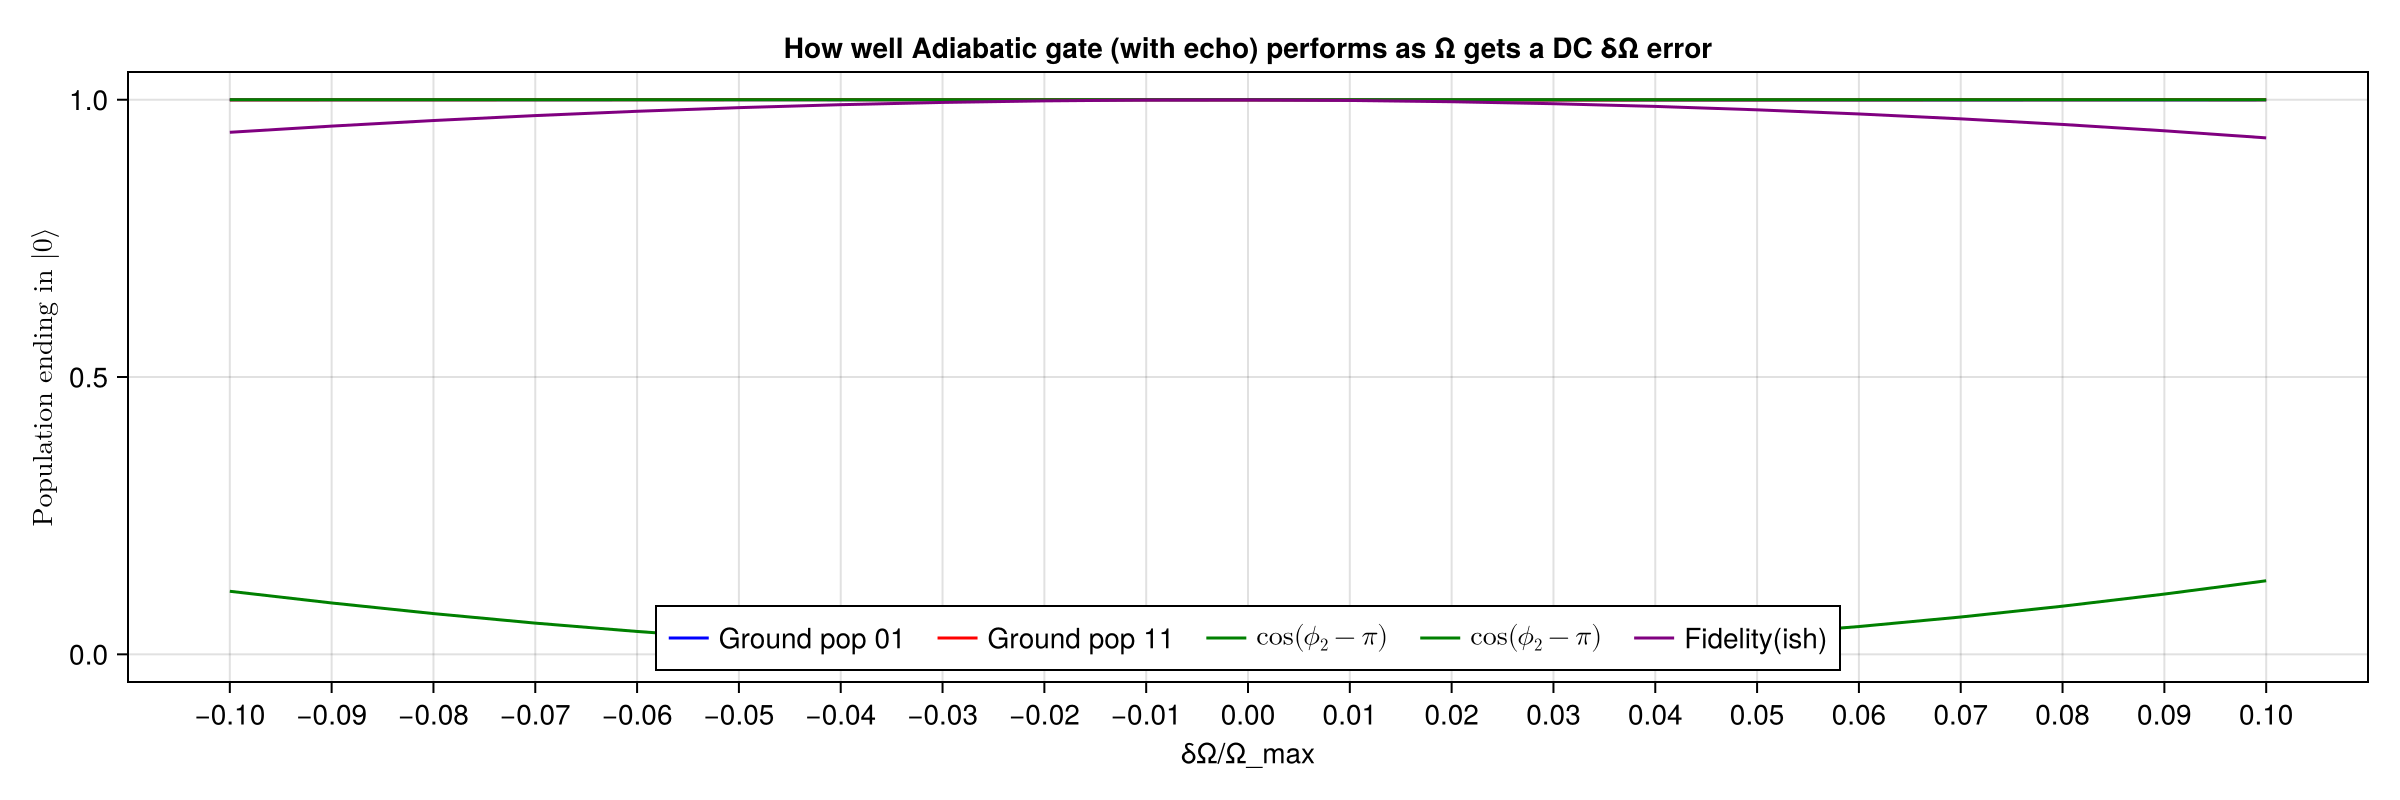

CairoMakie.Screen{IMAGE}


In [41]:
using CairoMakie
using RydbergUtils

Ω_max = 2.45025
δΩs = range(-0.1*Ω_max, 0.1*Ω_max, length=21)
Rx(θ) = ramanLaser(e_x*θ, 1)
Ry(θ) = ramanLaser(e_y*θ, 1)
Rz(θ) = ramanLaser(e_z*θ, 1)
I = identityTL(Rx(0))
Rx2(θ) = Rx(θ)⊗I + I⊗Rx(θ)
Ry2(θ) = Ry(θ)⊗I + I⊗Ry(θ)
Rz2(θ) = Rz(θ)⊗I + I⊗Rz(θ)

T_adiabatic = 4.3
T_IBA = 1.1562814

ibaHamiltonians = [iba_Hamiltonian(Vrr=500, Ω_max=Ω_max+δΩ, T=T_adiabatic) for δΩ in δΩs]
CZs = [CompositeHamiltonianTL([Rx2(π), ibaH, Rx2(π), ibaH, Rz2(π/2)]) for ibaH in ibaHamiltonians]

plotting_values = test_entangling_gate.(CZs)
ending_population_01 = getindex.(plotting_values, 1)
ending_population_11 = getindex.(plotting_values, 2)
cos_phase01 = (1 .+ cos.(getindex.(plotting_values, 5) .- π))/2
cos_phase11 = (1 .+ cos.(getindex.(plotting_values, 6) .- π))/2
fidelity = getindex.(plotting_values, 4)

# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well Adiabatic gate (with echo) performs as Ω gets a DC δΩ error",
    xlabel = "δΩ/Ω_max",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (δΩs ./ Ω_max)
)

# plotTs = Ts*totalTime(CZ)/Ts[end]
lines!(ax1, (δΩs ./ Ω_max), ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, (δΩs ./ Ω_max), ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, (δΩs ./ Ω_max), cos_phase01, color = :green, label = L"\cos(\phi_2 - \pi)")
lines!(ax1, (δΩs ./ Ω_max), cos_phase11, color = :green, label = L"\cos(\phi_2 - \pi)")
lines!(ax1, (δΩs ./ Ω_max), fidelity, color = :purple, label = "Fidelity(ish)")
# vlines!(ax1, [T_opt])

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

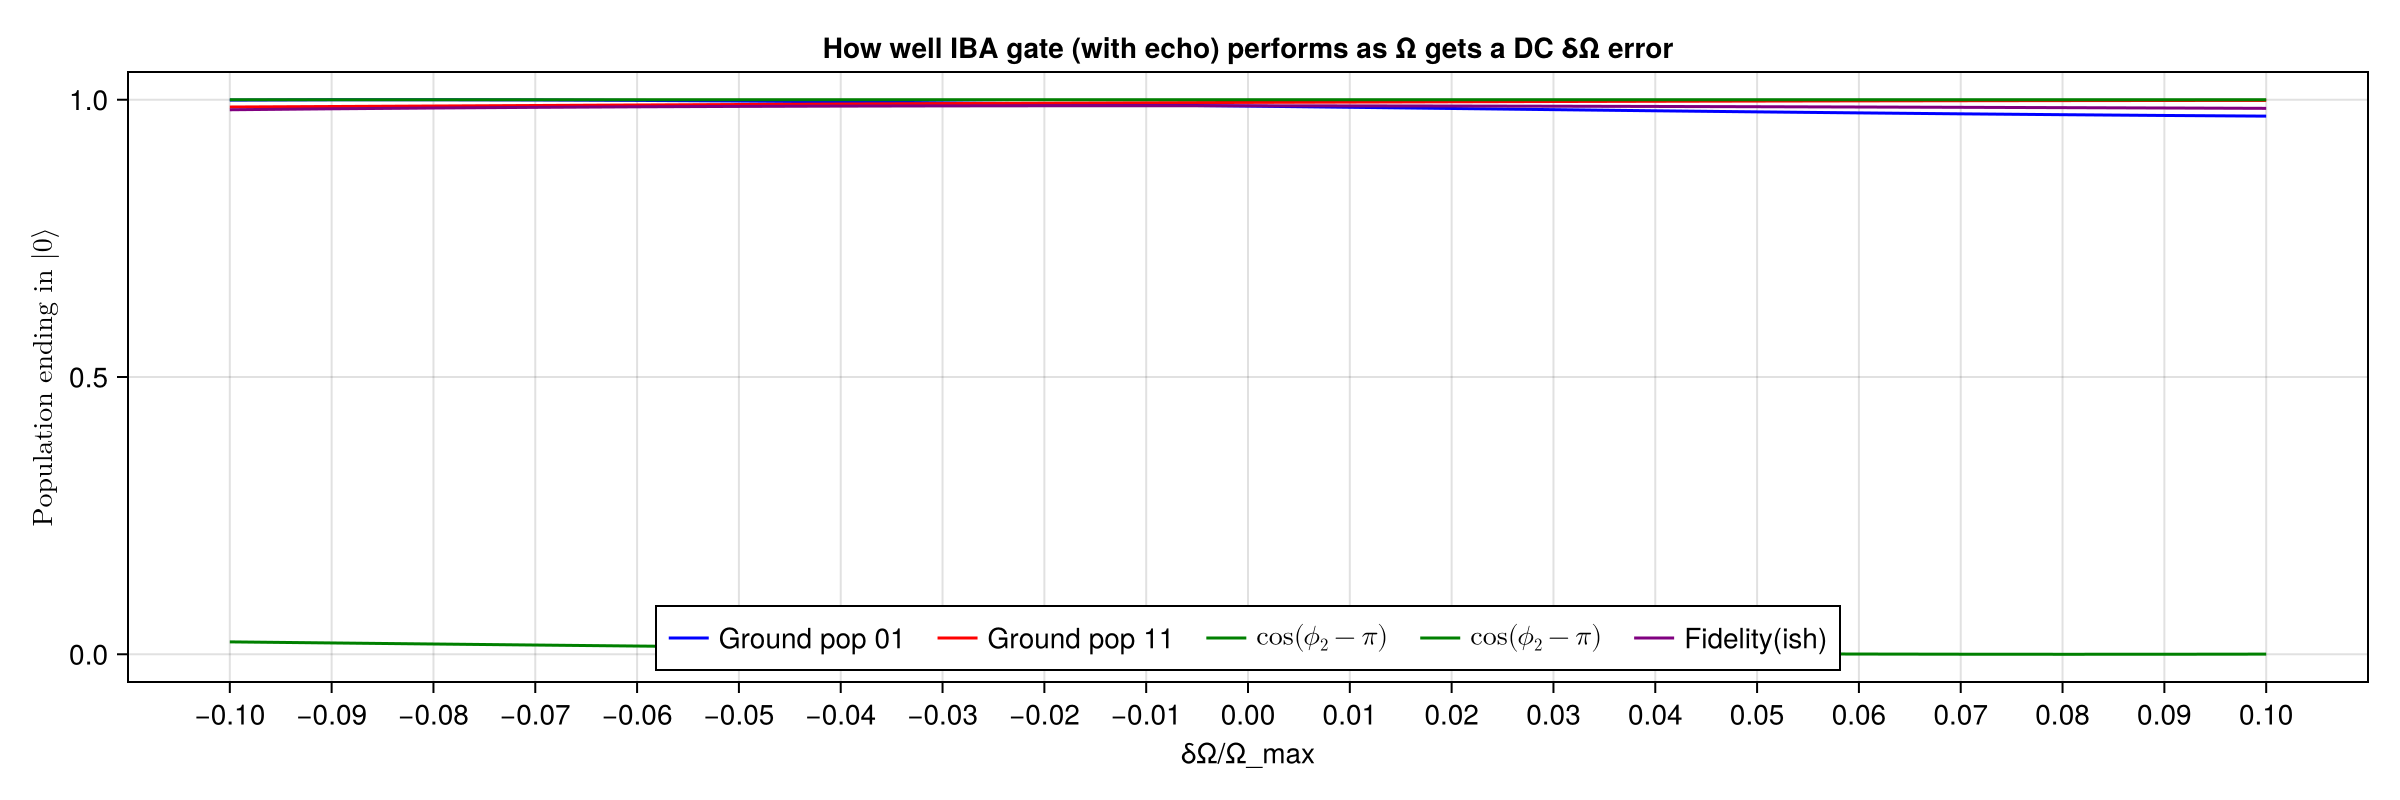

CairoMakie.Screen{IMAGE}


In [43]:
using CairoMakie
using RydbergUtils

Ω_max = 2.45025
δΩs = range(-0.1*Ω_max, 0.1*Ω_max, length=21)
Rx(θ) = ramanLaser(e_x*θ, 1)
Ry(θ) = ramanLaser(e_y*θ, 1)
Rz(θ) = ramanLaser(e_z*θ, 1)
I = identityTL(Rx(0))
Rx2(θ) = Rx(θ)⊗I + I⊗Rx(θ)
Ry2(θ) = Ry(θ)⊗I + I⊗Ry(θ)
Rz2(θ) = Rz(θ)⊗I + I⊗Rz(θ)

T_adiabatic = 4.3
T_IBA = 1.1562814

ibaHamiltonians = [iba_Hamiltonian(Vrr=500, Ω_max=Ω_max+δΩ, T=T_IBA) for δΩ in δΩs]
CZs = [CompositeHamiltonianTL([Rx2(π), ibaH, Rx2(π), ibaH, Rz2(-π/2)]) for ibaH in ibaHamiltonians]

plotting_values = test_entangling_gate.(CZs)
ending_population_01 = getindex.(plotting_values, 1)
ending_population_11 = getindex.(plotting_values, 2)
cos_phase01 = (1 .+ cos.(getindex.(plotting_values, 5) .- π))/2
cos_phase11 = (1 .+ cos.(getindex.(plotting_values, 6) .- π))/2
fidelity = getindex.(plotting_values, 4)

# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well IBA gate (with echo) performs as Ω gets a DC δΩ error",
    xlabel = "δΩ/Ω_max",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (δΩs ./ Ω_max)
)

# plotTs = Ts*totalTime(CZ)/Ts[end]
lines!(ax1, (δΩs ./ Ω_max), ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, (δΩs ./ Ω_max), ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, (δΩs ./ Ω_max), cos_phase01, color = :green, label = L"\cos(\phi_2 - \pi)")
lines!(ax1, (δΩs ./ Ω_max), cos_phase11, color = :green, label = L"\cos(\phi_2 - \pi)")
lines!(ax1, (δΩs ./ Ω_max), fidelity, color = :purple, label = "Fidelity(ish)")
# vlines!(ax1, [T_opt])

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)